# Pre-Class Assignment: Principal Component Analysis
# Day 21
# CMSE 202

## <p style="text-align: right;"> &#9989; Siddak Marwaha</p>

## Goals for today's pre-class assignment 

1. Review of Python Modules
2. Matrices and their eigenvalues/eigenvectors
3. Introduction to Principal Component Analysis
4. Example Application: The Iris data set
5. Understand the importance of scaling data

## Assignment instructions

**This assignment is due by 11:59 p.m. the day before class** and should be uploaded into the appropriate "Pre-class assignments" submission folder in the Desire2Learn website. 

----
## 1. Review of new (and old) Python modules
Run the following cell to import the modules we will be using in this pre-class assignment.

In [1]:
%pylab
%matplotlib inline

import scipy.linalg
import sklearn.decomposition as dec
import sklearn.datasets as ds
import seaborn as sns

sns.set_context("talk")

Using matplotlib backend: agg
Populating the interactive namespace from numpy and matplotlib


&#9989; **Question**: Identify the 5 modules we've imported, and their function. (the first one is done for you and the last one should be pretty familiar to you)

 <font size=+3>&#9998;</font> Do This - Erase this first line of this cell and finish describing the remaining four modules. Use appropriate markdown to make your answer readable. (double-click on this text to edit this cell, and hit shift+enter to save the text)
 
1. **numpy** (imported as np): A platform for numerical and scientific computing in Python. It provides multi-dimensional arrays (e.g., those from linear algebra) and tools for working with them.
2. **scipy.linalg**: A module that helps with linear algebra functions 
3. **sklearn.decomposition** (imported as dec): This module includes matrix decomposition algorithms, including among others PCA, NMF or ICA
4. **sklearn.datasets** (imported as ds): This package embeds some small sample datasets 
5. **seaborn** (imported as sns): Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics.

---

## 2. Developing some intuition about principal component analysis

The following videos (developed at Georgia Tech) are to help you gain an understanding and intuition about principal component analysis (PCA). PCA is one of the main techniques used in data science, exploratory data analysis and modeling.

You can watch the entire course here:

https://youtu.be/Ki2iHgKxRBo?list=PLAwxTw4SYaPl0N6-e1GvyLp5-MUMUjOKo

It's a great video series but we don't have time to cover it all.

&#9989; **Do This:** Watch the following video for an overview of PCA (don't worry about any references to "readings" from their course).

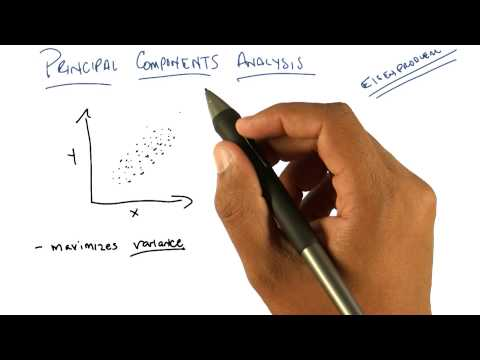

In [2]:
from IPython.display import YouTubeVideo
YouTubeVideo("kw9R0nD69OU",width=640,height=360)

&#9989; **Question**: PCA is trying to find the directions with maximal what? 

<font size=+3>&#9998;</font> Variance

&#9989; **Question**: What does it mean when two components are orthogonal?

<font size=+3>&#9998;</font> They are perpendicular

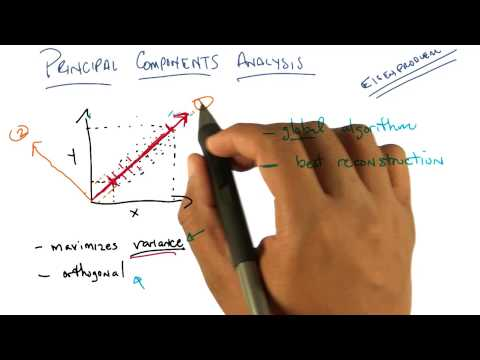

In [3]:
from IPython.display import YouTubeVideo
YouTubeVideo("_nZUhV-qhZA",width=640,height=360)

&#9989; **Question**: This video introduces a concept of "features" in a dataset. What are the names of the two original features represented in the graph shown in this video? What parts of the graph would represent the new features after the PCA is performed? 

<font size=+3>&#9998;</font> Two features are the x and y axis. After the PCA is performed, Principal and Second Principal Components are the features

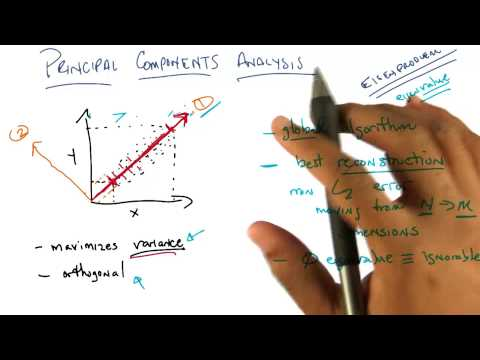

In [4]:
from IPython.display import YouTubeVideo
YouTubeVideo("kuzJJgPBrqc",width=640,height=360)

&#9989; **Question**: What does it mean if eigenvalue of a dimension is zero? How might performing PCA allow one to reduce the number of features we need to model to our data to get accurate results when making predictions?

<font size=+3>&#9998;</font> If eigenvalue of a dimension is zero, it means that it provides no information in the original space. You could throw that feature away if it has an eigenvalue of 0 thereby reducing dimensions.

---

## 3. Example Application: The Iris data set

Let's go back to the Iris dataset (the dataset that just keeps on giving!), but this time let's just load it using `sklearn`

In [13]:
# Load the dataset from sklearn and inspect it a bit
iris = ds.load_iris()
data = iris.data
target = iris.target
print(data.shape)

(150, 4)


Remember some of the details about the Iris data set. The three classes in the Iris dataset are represented by numbers in the 'target' vector:

1. Iris-setosa (n=50)
2. Iris-versicolor (n=50)
3. Iris-virginica (n=50)

There are four measurements (features) for each flower in the  'data' matrix: 

1. sepal length in cm
2. sepal width in cm
3. petal length in cm
4. petal width in cm
    
Example image for what these features correspond to on an actual iris:

<img src="http://nbviewer.jupyter.org/github/rasbt/pattern_classification/blob/master/Images/iris_petal_sepal.png" alt="Image of flower" width=400px>

#### Our Goal:

Create a model that given the four measurements can predicts the iris class.  We will use PCA to find axes that make it easier to separate the data into classes.  

### Step A: Try to visualize the features by plotting them.

&#9989; **Question**: Modify the following code to draw a scatterplot of the data for just the first and second axes of the data matrix (index 0 and 1).  Hint: use a similar vector notation as Step C below.

In [19]:
data[:,0]
data[:,1]

array([3.5, 3. , 3.2, 3.1, 3.6, 3.9, 3.4, 3.4, 2.9, 3.1, 3.7, 3.4, 3. ,
       3. , 4. , 4.4, 3.9, 3.5, 3.8, 3.8, 3.4, 3.7, 3.6, 3.3, 3.4, 3. ,
       3.4, 3.5, 3.4, 3.2, 3.1, 3.4, 4.1, 4.2, 3.1, 3.2, 3.5, 3.6, 3. ,
       3.4, 3.5, 2.3, 3.2, 3.5, 3.8, 3. , 3.8, 3.2, 3.7, 3.3, 3.2, 3.2,
       3.1, 2.3, 2.8, 2.8, 3.3, 2.4, 2.9, 2.7, 2. , 3. , 2.2, 2.9, 2.9,
       3.1, 3. , 2.7, 2.2, 2.5, 3.2, 2.8, 2.5, 2.8, 2.9, 3. , 2.8, 3. ,
       2.9, 2.6, 2.4, 2.4, 2.7, 2.7, 3. , 3.4, 3.1, 2.3, 3. , 2.5, 2.6,
       3. , 2.6, 2.3, 2.7, 3. , 2.9, 2.9, 2.5, 2.8, 3.3, 2.7, 3. , 2.9,
       3. , 3. , 2.5, 2.9, 2.5, 3.6, 3.2, 2.7, 3. , 2.5, 2.8, 3.2, 3. ,
       3.8, 2.6, 2.2, 3.2, 2.8, 2.8, 2.7, 3.3, 3.2, 2.8, 3. , 2.8, 3. ,
       2.8, 3.8, 2.8, 2.8, 2.6, 3. , 3.4, 3.1, 3. , 3.1, 3.1, 3.1, 2.7,
       3.2, 3.3, 3. , 2.5, 3. , 3.4, 3. ])

Text(0, 0.5, 'Sepal Width (in cm)')

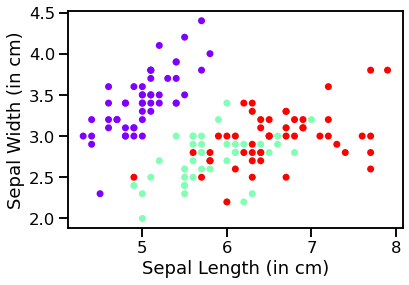

In [21]:
# DO THIS: Modify the code below to do a scatter plot with respect to the first two variables of the data
# i.e. all rows but just the first and second columns.

plt.scatter(data[:,0], data[:,1], c=target, s=30, cmap=plt.cm.rainbow);
plt.xlabel('Sepal Length (in cm)')
plt.ylabel('Sepal Width (in cm)')

# Don't forget to add axis labels


If done correctly the above should show different color dots for each of the different iris types.  As you can see, the classes do not separate clearly as two of the classes have a significant amount of overlap. Perhaps there are two new directions (axes) that separate the data better?

### Step B: Transform the data in terms of its principal components
Now we will use a PCA algorithm. Fortunately there is a simple PCA function available in the `scikit-learn` module [link](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html#sklearn.decomposition.PCA)

In [22]:
pca = dec.PCA()
pca_data = pca.fit_transform(data)

Out of curiosity, let's print the eigenvalues. The eigenvalues are stored in the **attribute** `explained_variance`. Remember from the video that low eigenvalues indicate less information. Big eigenvalues indicate more information. However, the eigenvalues are just numbers and do not indicate much so let's print also their ratio.

In [23]:
print("The eigenvalues are: ", pca.explained_variance_)
print("Their ratios are: ", pca.explained_variance_ratio_)

The eigenvalues are:  [4.22824171 0.24267075 0.0782095  0.02383509]
Their ratios are:  [0.92461872 0.05306648 0.01710261 0.00521218]


As you can see the last three eigenvalues are pretty small and do not provide much information. As a matter of fact 92% percent of the information is stored in the first eigenvalue.

However, these eigenvalues do not tell us which is the most important feature in the dataset. Principal Component Analysis is a global algorithm that "rotates" the data into new dimensions. 
Mathematically speaking the components are the eigenvectors. Let's print the components and check that they are orthogonal

In [24]:
for i, eigv in zip(["first", "second", "third", "fourth"], pca.components_):
    print(f"The elements of the {i} eigenvector are: ", eigv) 

The elements of the first eigenvector are:  [ 0.36138659 -0.08452251  0.85667061  0.3582892 ]
The elements of the second eigenvector are:  [ 0.65658877  0.73016143 -0.17337266 -0.07548102]
The elements of the third eigenvector are:  [-0.58202985  0.59791083  0.07623608  0.54583143]
The elements of the fourth eigenvector are:  [-0.31548719  0.3197231   0.47983899 -0.75365743]


&#9989; **Do this:** Write some code to check that all the eigenvectors are orthogonal to each other

In [38]:
# Put your code here
for i in range(3):
    print(np.dot(pca.components_[i],pca.components_[i+1]))
print(np.dot(pca.components_[3],pca.components_[0]))

3.885780586188048e-16
-2.220446049250313e-16
-1.942890293094024e-16
0.0


### Step C: Now plot the transformed data in terms of its first two principal components

Text(0, 0.5, 'PCA Component 2')

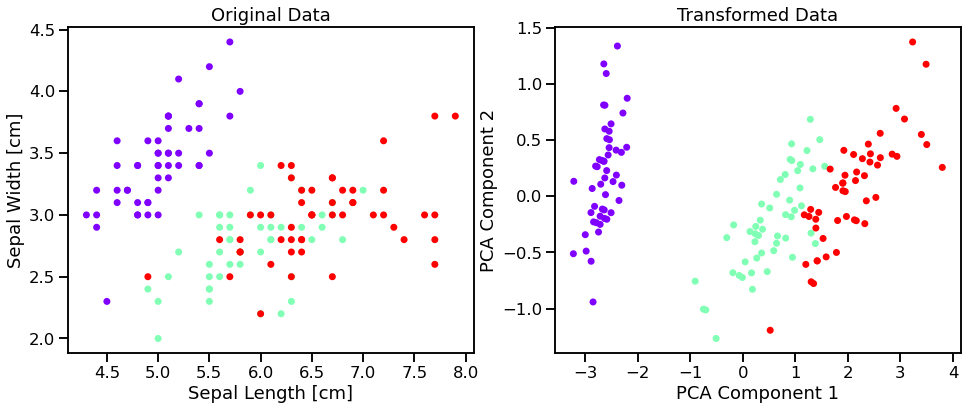

In [39]:
fig, ax = plt.subplots(1,2, figsize = (16, 6))
# Plot the original data
ax[0].scatter(iris.data[:,0], iris.data[:,1], c=target, s=30, cmap=plt.cm.rainbow)
ax[0].set_title("Original Data")
ax[0].set_xlabel("Sepal Length [cm]")
ax[0].set_ylabel("Sepal Width [cm]")
# Plot the transformed data
ax[1].scatter(pca_data[:,0], pca_data[:,1], c=target, s=30, cmap=plt.cm.rainbow)
ax[1].set_title("Transformed Data")
ax[1].set_xlabel("PCA Component 1")
ax[1].set_ylabel("PCA Component 2")

&#9989; **Question:**  Describe in words the differences between the above graphs. They are representing the same data. Why would we prefer to use the features produced by Step C?

<font size=+3>&#9998;</font> We would prefer to use the features produced by step C since they are separable.

## 5. Scaling Data


As mentioned above PCA finds the dimensions with the highest variance. However, it can be the case that some of the features in your dataset lie on very different ranges. For example, think of a dataset containing the salaries and heights of all the people in a company. The range of salaries is much wider than the range of heights, e.g. from less than 15 USD/hour for the clerk to Millions of USD for the CEO while the heights of employees changes only over several inches. 

&#9989; **Do this:** Read the two guides below and answer the following questions

[Importance of Feature Scaling](https://scikit-learn.org/stable/auto_examples/preprocessing/plot_scaling_importance.html)

[PreProcessing Data](https://scikit-learn.org/stable/modules/preprocessing.html#preprocessing-scaler) Read up to section 6.3.1.3 included

[Compare the effect of different scalers on data with outliers](https://scikit-learn.org/stable/auto_examples/preprocessing/plot_all_scaling.html#sphx-glr-auto-examples-preprocessing-plot-all-scaling-py) 


1. Why is it important to scale data ? If one component (e.g. human height) varies less than another (e.g. weight) because of their respective scales (meters vs. kilos), PCA might determine that the direction of maximal variance more closely corresponds with the ‘weight’ axis, if those features are not scaled

2. What scaler is used in the first article? StandardScaler

3. How many linear scaler can you find in `scikit-learn` ? List all the ones you find. 1. Standardization, 2. Non-linear transformation, 3. Normalization, 4. Encoding categorical features, 5. Discretization, 6. Imputation of missing values, 7. Generating polynomial features, 8. Custom transformers

4. How do you preprocess the data when it has outliers ? What scaler do you use and why ? Robust Scaling, because this scaling technique is based on the median which is independent of the outliers.

5. List at least two non-linear transformers ? Mapping to Uniform Distribution, Mapping to Gausian distribution.

<font size=+3>&#9998;</font> Do This - Erase the contents of this cell and replace it with your answer to the above question!  (double-click on this text to edit this cell, and hit shift+enter to save the text)

---
## 6. Group Project Check-ins

### Summary
    * Give a short (3-5 minutes) presentation on your project
    * Check-in and ensure your project is in a good place for final presentation
    * Presentation should focus on results
    * Give feedback to classmates on their projects
    * As a group, meet with your instructor to discuss implementing your feedback

### Why are we doing this?
These presentations (effectively) serve as a second checkpoint for your projects. We want to ensure that you and your group have made solid progress in completing your project, and are ready to give your full presentations the following week. This will also serve as an opportunity for you to give and receive feedback on your projects.  
Finally, you will be expected to meet with your instructor (as a group) to go over your feedback and make a plan to finish out your project. Your instructor will provide further details on the scheduling of these meetings.

### Presentations: What will you need to do?
By the time of these presentations you should be ~75% of the way done with your projects. We expect you to have implemented a methodology to answer your question and have results from this implementation. Your presentation should focus on these results.

You will have 3-5 minutes to talk through your slides Your presentation must include the following elements:

    - The question you’re answering
    - A brief description of your methodology (no more than two sentences)
    - Your results, in the form of visualizations
    - The conclusions you’ve drawn from these results
    - Plans for finishing your project
    
Your instructor will share either a Google Drive or OneDrive with the entire class, where you can upload your slide(s). Make sure to upload your slide(s) early so you can handle any formatting issues that may come up.


### Feedback: What will you need to do?
We will provide you with a form to fill out to give feedback to other groups on their projects. For each group, you will be asked to: 
Give a brief (one-sentence) description of the project
Evaluate their presentation on the five criteria listed above
Make at least one suggestion for how to improve the project

### Schedule a meeting
Your group will also need to schedule a time to meet with your instructor to discuss the feedback you receive. During this time you will sketch out a plan for finishing up your project. More details on the scheduling process will be provided by your instructor.


Your final project will be due at:

- **11:59PM on Sunday December 3 if you are in Section 001 or Section 002**.
- **11:59PM on Monday December 4 if you are in Section 003**.

**You may wish to review the project grading rubric and requirements available [here](https://msu-cmse-courses.github.io/cmse202-F22-jb/course_materials/CMSE202_FinalProjectRequirementsAndGradingRubric.html) on the course website.**

---
## Follow-up Questions

Copy and paste the following questions into the appropriate box in the assignment survey include below and answer them there. (Note: You'll have to fill out the assignment number and go to the "NEXT" section of the survey to paste in these questions.)

1. When doing a principle component analysis (PCA), the goal is to find a new set of axes that maximize what?

2. When you perform PCA, what do large eigenvalues indicate versus small eigenvalues?

3. Why is important to scale data ? 

4. How do you deal with outliers ?

----
# Assignment wrap-up

Please fill out the form that appears when you run the code below.  **You must completely fill this out in order to receive credit for the assignment!**

In [40]:
from IPython.display import HTML
HTML(
"""
<iframe 
	src="https://cmse.msu.edu/cmse202-pc-survey" 
	width="800px" 
	height="600px" 
	frameborder="0" 
	marginheight="0" 
	marginwidth="0">
	Loading...
</iframe>
"""
)

---------
### Congratulations, you're done with your pre-class assignment!

Now, you just need to submit this assignment by uploading it to the course <a href="https://d2l.msu.edu/">Desire2Learn</a> web page for today's submission folder (Don't forget to add your name in the first cell).

&#169; Copyright 2021 Department of Computational Mathematics, Science and Engineering at Michigan State University